# GPT (Decoder-Only Transformer) for NLP Text Classification

This notebook follows the same style as your Assignment 8 implementation: custom transformer components, clean preprocessing pipeline, and explicit training/evaluation loops.

Task: **SMS Spam Detection** (binary text classification) using a decoder-only GPT-style model.

Dataset is downloaded freshly from UCI into a new local folder (`data_external/`).

In [1]:
# Imports
import copy
import math
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from nltk.tokenize import word_tokenize

In [2]:
# Seeding and device
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

print('Device:', device)

Device: cuda


## 1) Download and Load Dataset

We download SMS Spam Collection directly from UCI (fresh download path), then create train/val/test splits.

In [3]:
DATA_DIR = Path('data_external')
DATA_DIR.mkdir(parents=True, exist_ok=True)

import urllib.request

SMS_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
ZIP_PATH = DATA_DIR / 'sms_spam_collection.zip'
TXT_PATH = DATA_DIR / 'SMSSpamCollection'

if not TXT_PATH.exists():
    if not ZIP_PATH.exists():
        print('Downloading dataset...')
        urllib.request.urlretrieve(SMS_URL, ZIP_PATH)
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATA_DIR)

texts, labels = [], []
label_map = {'ham': 0, 'spam': 1}
inv_label_map = {0: 'ham', 1: 'spam'}

with open(TXT_PATH, encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue
        lbl, msg = line.split('	', maxsplit=1)
        texts.append(msg)
        labels.append(label_map[lbl])

texts = np.array(texts)
labels = np.array(labels)

print(f'Total samples: {len(texts)}')
print(f'Ham: {(labels == 0).sum()} | Spam: {(labels == 1).sum()}')

Extracting dataset...
Total samples: 5574
Ham: 4827 | Spam: 747


In [4]:
def stratified_split_indices(labels, train_ratio=0.8, val_ratio=0.1, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)

        n = len(idx)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = stratified_split_indices(labels)

train_texts, train_labels = texts[train_idx].tolist(), labels[train_idx].tolist()
val_texts, val_labels = texts[val_idx].tolist(), labels[val_idx].tolist()
test_texts, test_labels = texts[test_idx].tolist(), labels[test_idx].tolist()

print(f'Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')

Train: 4458 | Val: 556 | Test: 560


## 2) Preprocessing Pipeline

Tokenization + `<sos>/<eos>` + fixed-length padding, consistent with your Assignment 8 style.

In [5]:
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3
SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']

MAX_LEN = 96

def text_preprocess_pipeline(text_list, max_len=MAX_LEN):
    processed = []
    for text in tqdm(text_list, desc='Tokenising', leave=False):
        text = text.lower().strip()
        tokens = word_tokenize(text, language='english')
        tokens = tokens[:max_len - 2]
        tokens = ['<sos>'] + tokens + ['<eos>']
        tokens += ['<pad>'] * (max_len - len(tokens))
        processed.append(tokens)
    return processed

def build_vocab(token_lists, min_freq=2):
    token_to_idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
    idx_to_token = {i: tok for i, tok in enumerate(SPECIAL_TOKENS)}
    freq = Counter()

    for tokens in token_lists:
        freq.update(tokens)

    next_idx = len(SPECIAL_TOKENS)
    for tok, c in freq.items():
        if tok in token_to_idx:
            continue
        if c >= min_freq:
            token_to_idx[tok] = next_idx
            idx_to_token[next_idx] = tok
            next_idx += 1

    return token_to_idx, idx_to_token, freq

def convert_text_to_idx(token_lists, token_to_idx):
    converted = []
    for tokens in token_lists:
        ids = [token_to_idx.get(tok, UNK_IDX) for tok in tokens]
        converted.append(ids)
    return converted

In [6]:
train_tok = text_preprocess_pipeline(train_texts)
val_tok = text_preprocess_pipeline(val_texts)
test_tok = text_preprocess_pipeline(test_texts)

tok2idx, idx2tok, token_freq = build_vocab(train_tok, min_freq=2)

train_ids = convert_text_to_idx(train_tok, tok2idx)
val_ids = convert_text_to_idx(val_tok, tok2idx)
test_ids = convert_text_to_idx(test_tok, tok2idx)

VOCAB_SIZE = len(tok2idx)
NUM_CLASSES = 2

print(f'Vocabulary size: {VOCAB_SIZE}')
print('Sample tokens:', train_tok[0][:20])

Tokenising:   0%|          | 0/4458 [00:00<?, ?it/s]

Tokenising:   0%|          | 0/556 [00:00<?, ?it/s]

Tokenising:   0%|          | 0/560 [00:00<?, ?it/s]

Vocabulary size: 3809
Sample tokens: ['<sos>', 'yo', ',', 'you', 'around', '?', 'just', 'got', 'my', 'car', 'back', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


## 3) Dataloader

In [7]:
BATCH_SIZE = 256 if device == 'cuda' else 64

class TextClassificationDataset(Dataset):
    def __init__(self, x_ids, y_labels):
        self.x = torch.tensor(x_ids, dtype=torch.long)
        self.y = torch.tensor(y_labels, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(TextClassificationDataset(train_ids, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_ids, val_labels), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TextClassificationDataset(test_ids, test_labels), batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches -> Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches -> Train: 18 | Val: 3 | Test: 3


## 4) GPT Decoder-Only Model (From Scratch)

This is a causal decoder stack with masked self-attention and a classification head.

In [8]:
class EmbeddingLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.d_model = d_model

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncodingLayer(nn.Module):
    def __init__(self, d_model, max_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, _ = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        B, _, T, _ = x.size()
        return x.transpose(1, 2).contiguous().view(B, T, self.d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))
        probs = torch.softmax(scores, dim=-1)
        probs = self.dropout(probs)
        out = torch.matmul(probs, V)
        return out

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        out = self.scaled_dot_product_attention(Q, K, V, mask)
        out = self.combine_heads(out)
        return self.W_o(out)

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

class GPTDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.feed_forward(x)))
        return x

class GPTClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.token_embedding = EmbeddingLayer(d_model, vocab_size)
        self.pos_encoding = PositionalEncodingLayer(d_model, max_len, dropout)

        self.decoder_layers = nn.ModuleList([
            GPTDecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def _make_causal_pad_mask(self, x):
        _, T = x.size()
        causal = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        pad = (x == PAD_IDX).unsqueeze(1).unsqueeze(2)
        return causal.unsqueeze(0).unsqueeze(0) | pad

    def forward(self, x):
        mask = self._make_causal_pad_mask(x)

        h = self.pos_encoding(self.token_embedding(x))
        for layer in self.decoder_layers:
            h = layer(h, mask)

        lengths = (x != PAD_IDX).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0)
        batch_idx = torch.arange(x.size(0), device=x.device)
        pooled = h[batch_idx, lengths]

        logits = self.classifier(self.dropout(pooled))
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
# Hardware-aware hyperparameters (suited for RTX 5070 12 GB)
if device == 'cuda':
    D_MODEL = 320
    NUM_HEADS = 8
    NUM_LAYERS = 6
    D_FF = 1280
    DROPOUT = 0.15
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 1e-2
    N_EPOCHS = 10
else:
    D_MODEL = 192
    NUM_HEADS = 6
    NUM_LAYERS = 4
    D_FF = 768
    DROPOUT = 0.15
    LEARNING_RATE = 4e-4
    WEIGHT_DECAY = 1e-2
    N_EPOCHS = 8

model = GPTClassifier(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

print(f'Model parameters: {count_parameters(model) / 1e6:.3f}M')

Model parameters: 8.617M


## 5) Training and Evaluation Utilities

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

amp_enabled = (device == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_acc = 0.0

    bar = tqdm(loader, leave=False)
    for x, y in bar:
        x = x.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=amp_enabled):
            logits = model(x)
            loss = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        acc = accuracy_from_logits(logits, y)
        total_loss += loss.item()
        total_acc += acc

        bar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{acc:.4f}')

    return total_loss / len(loader), total_acc / len(loader)

def fit_model(model, train_loader, val_loader, n_epochs):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_val_acc = -1.0
    best_weights = None

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer=optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, optimizer=None)

        scheduler.step(va_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch:02d}/{n_epochs} | '
            f'Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | '
            f'Val Loss: {va_loss:.4f}, Val Acc: {va_acc:.4f}'
        )

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return history

C:\Users\shamb\AppData\Local\Temp\ipykernel_16364\720071133.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


In [11]:
history = fit_model(model, train_loader, val_loader, N_EPOCHS)

  0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\shamb\AppData\Local\Temp\ipykernel_16364\720071133.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.6001, Train Acc: 0.7751 | Val Loss: 0.3940, Val Acc: 0.8775


  0%|          | 0/18 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.1361, Train Acc: 0.9917 | Val Loss: 0.1984, Val Acc: 0.9682


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.1312, Train Acc: 0.9945 | Val Loss: 0.2205, Val Acc: 0.9643


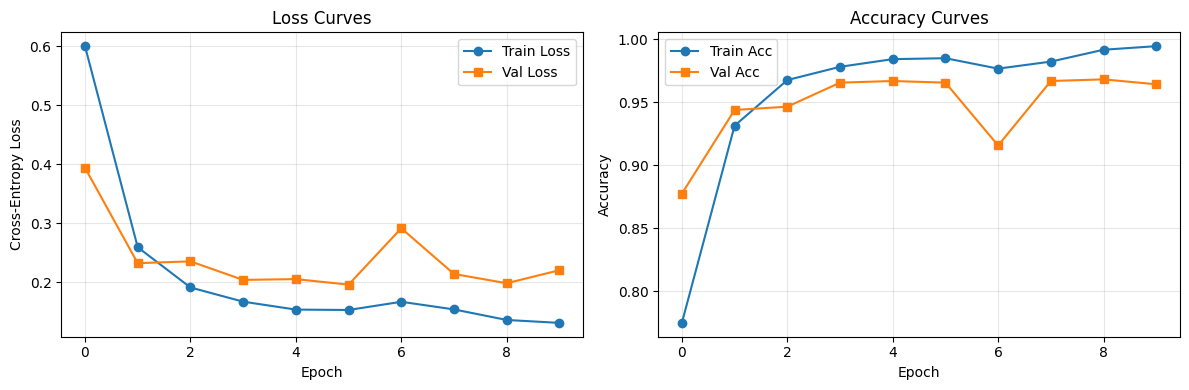

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], marker='o', label='Train Loss')
plt.plot(history['val_loss'], marker='s', label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], marker='o', label='Train Acc')
plt.plot(history['val_acc'], marker='s', label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 6) Test Set Evaluation + Sample Predictions

Test Accuracy : 0.9839
Precision (spam): 0.9718
Recall    (spam): 0.9079
F1-score  (spam): 0.9388

Confusion Matrix [rows=true, cols=pred]:
[[482   2]
 [  7  69]]


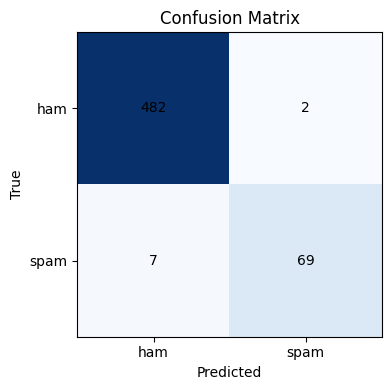

In [13]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        y_true.extend(y.numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs[:, 1].cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true, y_pred, y_prob = predict_loader(model, test_loader)

test_acc = (y_true == y_pred).mean()
cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
precision = tp / (tp + fp + 1e-12)
recall = tp / (tp + fn + 1e-12)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Precision (spam): {precision:.4f}')
print(f'Recall    (spam): {recall:.4f}')
print(f'F1-score  (spam): {f1:.4f}')
print('\nConfusion Matrix [rows=true, cols=pred]:')
print(cm)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['ham', 'spam'])
plt.yticks([0, 1], ['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

In [14]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(test_texts), size=8, replace=False)

print('=' * 100)
print('Sample Predictions')
print('=' * 100)

for i, idx in enumerate(sample_indices, start=1):
    true_lbl = test_labels[idx]

    x = torch.tensor([test_ids[idx]], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred_lbl = int(np.argmax(probs))

    print(f'Example {i:02d}')
    print(f'  Text       : {test_texts[idx]}')
    print(f'  True Label : {inv_label_map[true_lbl]}')
    print(f'  Pred Label : {inv_label_map[pred_lbl]}')
    print(f'  P(spam)    : {probs[1]:.4f}')
    print('-' * 100)

Sample Predictions
Example 01
  Text       : Can you plz tell me the ans. BSLVYL sent via fullonsms.com
  True Label : ham
  Pred Label : ham
  P(spam)    : 0.0285
----------------------------------------------------------------------------------------------------
Example 02
  Text       : Did you say bold, then torch later. Or one torch and 2bold?
  True Label : ham
  Pred Label : ham
  P(spam)    : 0.0259
----------------------------------------------------------------------------------------------------
Example 03
  Text       : Really good:)dhanush rocks once again:)
  True Label : ham
  Pred Label : ham
  P(spam)    : 0.0234
----------------------------------------------------------------------------------------------------
Example 04
  Text       : So lets make it saturday or monday as per convenience.
  True Label : ham
  Pred Label : ham
  P(spam)    : 0.0312
----------------------------------------------------------------------------------------------------
Example 05
  Text  

### Notes
- This is decoder-only (GPT-style) because each token only attends to earlier tokens via a causal mask.
- For your system (RTX 5070 12 GB), current settings are moderate and should run comfortably.
- If you want higher accuracy, try increasing `N_EPOCHS`, `MAX_LEN`, or `D_MODEL` slightly.

## 7) Decoder-Only Variant with `nn.MultiheadAttention`

This mirrors your Assignment 8 comparison style: same overall GPT decoder setup, but replacing custom attention with PyTorch `nn.MultiheadAttention` to compare practical training behavior and performance.

In [15]:
class GPTDecoderLayer_nnMHA(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None, key_padding_mask=None):
        attn_out, _ = self.self_attn(
            query=x,
            key=x,
            value=x,
            attn_mask=causal_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.feed_forward(x)))
        return x

class GPTClassifier_nnMHA(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.token_embedding = EmbeddingLayer(d_model, vocab_size)
        self.pos_encoding = PositionalEncodingLayer(d_model, max_len, dropout)

        self.decoder_layers = nn.ModuleList([
            GPTDecoderLayer_nnMHA(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def _make_masks(self, x):
        _, T = x.size()
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool),
            diagonal=1
        )
        key_padding_mask = (x == PAD_IDX)
        return causal_mask, key_padding_mask

    def forward(self, x):
        causal_mask, key_padding_mask = self._make_masks(x)

        h = self.pos_encoding(self.token_embedding(x))
        for layer in self.decoder_layers:
            h = layer(h, causal_mask=causal_mask, key_padding_mask=key_padding_mask)

        lengths = (x != PAD_IDX).sum(dim=1) - 1
        lengths = torch.clamp(lengths, min=0)
        batch_idx = torch.arange(x.size(0), device=x.device)
        pooled = h[batch_idx, lengths]

        logits = self.classifier(self.dropout(pooled))
        return logits

In [16]:
model_mha = GPTClassifier_nnMHA(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

print(f'Model (nn.MHA) parameters: {count_parameters(model_mha) / 1e6:.3f}M')

Model (nn.MHA) parameters: 8.617M


In [17]:
def run_epoch_generic(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_acc = 0.0

    bar = tqdm(loader, leave=False)
    for x, y in bar:
        x = x.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=amp_enabled):
            logits = model(x)
            loss = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        acc = accuracy_from_logits(logits, y)
        total_loss += loss.item()
        total_acc += acc

        bar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{acc:.4f}')

    return total_loss / len(loader), total_acc / len(loader)

def fit_model_generic(model, train_loader, val_loader, n_epochs, learning_rate, weight_decay):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = -1.0
    best_weights = None

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = run_epoch_generic(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler
        )
        va_loss, va_acc = run_epoch_generic(
            model, val_loader, criterion, optimizer=None, scaler=scaler
        )

        scheduler.step(va_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f'[nn.MHA] Epoch {epoch:02d}/{n_epochs} | '
            f'Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | '
            f'Val Loss: {va_loss:.4f}, Val Acc: {va_acc:.4f}'
        )

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return history

In [18]:
history_mha = fit_model_generic(
    model=model_mha,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

[nn.MHA] Epoch 01/10 | Train Loss: 0.4902, Train Acc: 0.8487 | Val Loss: 0.4213, Val Acc: 0.8368


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

[nn.MHA] Epoch 09/10 | Train Loss: 0.1391, Train Acc: 0.9918 | Val Loss: 0.2006, Val Acc: 0.9731


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

[nn.MHA] Epoch 10/10 | Train Loss: 0.1314, Train Acc: 0.9954 | Val Loss: 0.1939, Val Acc: 0.9770


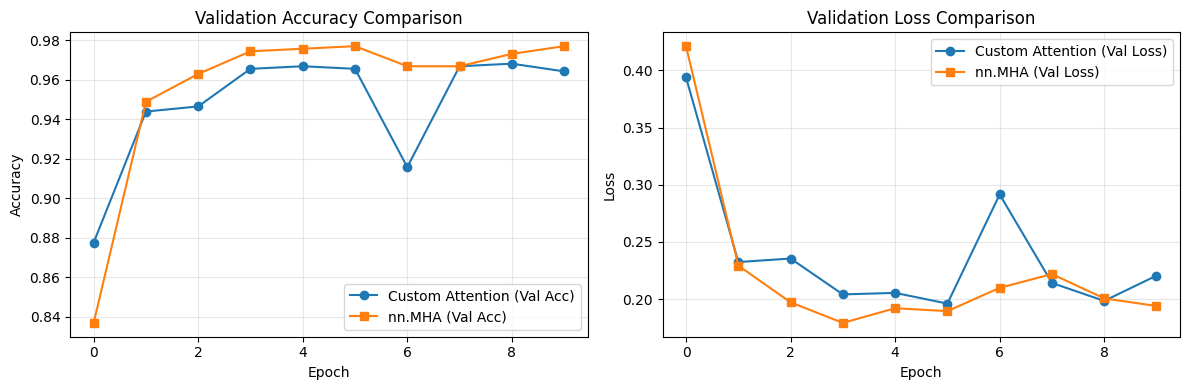

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['val_acc'], marker='o', label='Custom Attention (Val Acc)')
plt.plot(history_mha['val_acc'], marker='s', label='nn.MHA (Val Acc)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_loss'], marker='o', label='Custom Attention (Val Loss)')
plt.plot(history_mha['val_loss'], marker='s', label='nn.MHA (Val Loss)')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
y_true_mha, y_pred_mha, y_prob_mha = predict_loader(model_mha, test_loader)

test_acc_mha = (y_true_mha == y_pred_mha).mean()
cm_mha = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true_mha, y_pred_mha):
    cm_mha[t, p] += 1

tn2, fp2, fn2, tp2 = cm_mha[0, 0], cm_mha[0, 1], cm_mha[1, 0], cm_mha[1, 1]
precision_mha = tp2 / (tp2 + fp2 + 1e-12)
recall_mha = tp2 / (tp2 + fn2 + 1e-12)
f1_mha = 2 * precision_mha * recall_mha / (precision_mha + recall_mha + 1e-12)

print('Custom Attention Model:')
print(f'  Test Accuracy      : {test_acc:.4f}')
print(f'  Precision (spam)   : {precision:.4f}')
print(f'  Recall (spam)      : {recall:.4f}')
print(f'  F1-score (spam)    : {f1:.4f}')

print('\nnn.MultiheadAttention Model:')
print(f'  Test Accuracy      : {test_acc_mha:.4f}')
print(f'  Precision (spam)   : {precision_mha:.4f}')
print(f'  Recall (spam)      : {recall_mha:.4f}')
print(f'  F1-score (spam)    : {f1_mha:.4f}')

Custom Attention Model:
  Test Accuracy      : 0.9839
  Precision (spam)   : 0.9718
  Recall (spam)      : 0.9079
  F1-score (spam)    : 0.9388

nn.MultiheadAttention Model:
  Test Accuracy      : 0.9786
  Precision (spam)   : 0.9706
  Recall (spam)      : 0.8684
  F1-score (spam)    : 0.9167


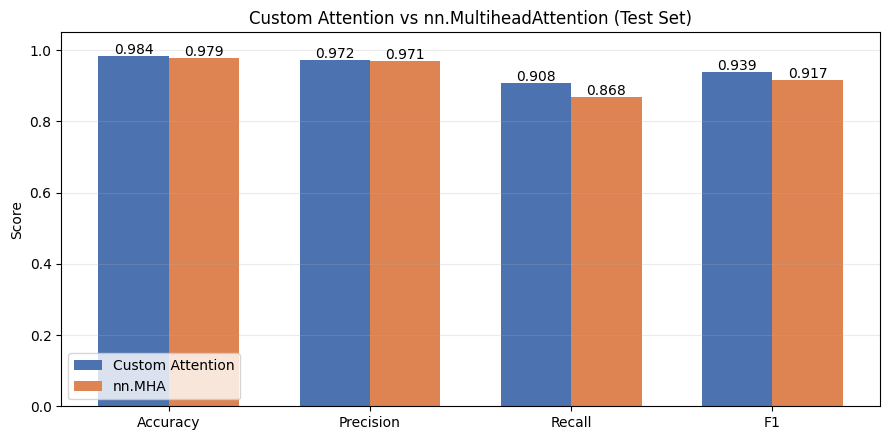

In [21]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
custom_metrics = [test_acc, precision, recall, f1]
mha_metrics = [test_acc_mha, precision_mha, recall_mha, f1_mha]

x = np.arange(len(metric_names))
w = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(x - w / 2, custom_metrics, width=w, label='Custom Attention', color='#4C72B0')
plt.bar(x + w / 2, mha_metrics, width=w, label='nn.MHA', color='#DD8452')

for i, v in enumerate(custom_metrics):
    plt.text(i - w / 2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(mha_metrics):
    plt.text(i + w / 2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.xticks(x, metric_names)
plt.ylim(0.0, 1.05)
plt.ylabel('Score')
plt.title('Custom Attention vs nn.MultiheadAttention (Test Set)')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [22]:
rng = np.random.default_rng(SEED + 7)
sample_indices_cmp = rng.choice(len(test_texts), size=6, replace=False)

print('=' * 110)
print('Sample Predictions Comparison (Custom Attention vs nn.MHA)')
print('=' * 110)

for i, idx in enumerate(sample_indices_cmp, start=1):
    x_sample = torch.tensor([test_ids[idx]], dtype=torch.long, device=device)

    with torch.no_grad():
        logits_custom = model(x_sample)
        probs_custom = torch.softmax(logits_custom, dim=1).squeeze(0).cpu().numpy()
        pred_custom = int(np.argmax(probs_custom))

        logits_mha = model_mha(x_sample)
        probs_mha = torch.softmax(logits_mha, dim=1).squeeze(0).cpu().numpy()
        pred_mha = int(np.argmax(probs_mha))

    print(f'Example {i:02d}')
    print(f'  Text                 : {test_texts[idx]}')
    print(f'  True Label           : {inv_label_map[test_labels[idx]]}')
    print(f'  Custom Pred / P(spam): {inv_label_map[pred_custom]} / {probs_custom[1]:.4f}')
    print(f'  nn.MHA Pred / P(spam): {inv_label_map[pred_mha]} / {probs_mha[1]:.4f}')
    print('-' * 110)

Sample Predictions Comparison (Custom Attention vs nn.MHA)
Example 01
  Text                 : In xam hall boy asked girl Tell me the starting term for dis answer I can den manage on my own After lot of hesitation n lookin around silently she said THE! intha ponnungale ipaditan;)
  True Label           : ham
  Custom Pred / P(spam): ham / 0.0273
  nn.MHA Pred / P(spam): ham / 0.0188
--------------------------------------------------------------------------------------------------------------
Example 02
  Text                 : How's ur paper?
  True Label           : ham
  Custom Pred / P(spam): ham / 0.0213
  nn.MHA Pred / P(spam): ham / 0.0195
--------------------------------------------------------------------------------------------------------------
Example 03
  Text                 : Is fujitsu s series lifebook good?
  True Label           : ham
  Custom Pred / P(spam): ham / 0.0230
  nn.MHA Pred / P(spam): ham / 0.0300
-----------------------------------------------------------